In [154]:
# Colab 한글 폰트 설치
!apt-get install -y fonts-nanum -qq
import matplotlib.font_manager as fm
# fm._rebuild()  # matplotlib 3.2에서 제거됨. fontManager.addfont()로 대체
import glob
for f in glob.glob('/usr/share/fonts/truetype/nanum/*.ttf'):
    fm.fontManager.addfont(f)

# 심장병 예측 모델 (Heart Disease Prediction)

**데이터셋**: Cleveland Heart Disease Dataset (303 samples, 14 features)  
**목표**: 환자의 임상 수치를 기반으로 심장병 유무(이진 분류)를 예측  
**모델**: KNN, MLP, RandomForest  
**출처**: https://www.kaggle.com/datasets/cherngs/heart-disease-cleveland-uci  

---
### 주요 특징
- 13개 임상 특징(나이, 성별, 흉통 유형, 혈압, 콜레스테롤 등)
- 각 모델의 하이퍼파라미터 최적화 후 성능 비교
- Accuracy, Recall, F1-Score, ROC-AUC 기반 평가

In [155]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm

# set font properties using rcParams
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.style'] = 'italic'

In [156]:
from google.colab import drive
drive.mount('/content/drive')

csv_path = '/content/drive/MyDrive/heart_cleveland_upload.csv'

df  = pd.read_csv(csv_path)
df1 = pd.read_csv(csv_path)
df4 = pd.read_csv(csv_path)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [157]:
df.shape

(297, 14)

In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [159]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


In [160]:
#data cleaning , scaling and encoding
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition'],
      dtype='object')

In [161]:
df.columns = ['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholesterol',
              'fasting_blood_sugar', 'rest_ecg', 'max_heart_rate_achieved',
              'exercise_induced_angina', 'st_depression', 'st_slope', 'ca', 'thalassemia', 'target']

In [162]:
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,ca,thalassemia,target
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [163]:
df1.columns = ['나이', '성별', '가슴 통증 유형', '휴식 혈압', '콜레스테롤', '공복 혈당',
               '휴식 심전도', '최대 심박수 달성', '운동 유발 협심증', 'st경사수치',
               '최대 st경사수치', '주요혈관수', '지중해빈혈', '심장병유무']

In [164]:
df4.columns = ['나이', '성별', '가슴 통증 유형', '휴식 혈압', '콜레스테롤', '공복 혈당',
               '휴식 심전도', '최대 심박수 달성', '운동 유발 협심증', 'st경사수치',
               '최대 st경사수치', '주요혈관수', '지중해빈혈', '심장병유무']

In [165]:
# 데이터 품질 확인 및 이상치 처리
# cholesterol == 0: 생물학적으로 불가능한 값 → 실제 결측값으로 처리
# ca == 4: 클리블랜드 데이터셋에서 결측값 인코딩 (실제 범위: 0~3)
print('이상치 탐지:')
print(f'  콜레스테롤 == 0 (결측 인코딩): {(df["cholesterol"] == 0).sum()}건')
print(f'  ca == 4 (결측 인코딩): {(df["ca"] == 4).sum()}건')

# df (모델링용): cholesterol 0 → NaN → 중앙값으로 대체
df['cholesterol'] = df['cholesterol'].replace(0, np.nan)
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

# df1, df4 (시각화용): 콜레스테롤 0 → 중앙값으로 대체
for d in [df1, df4]:
    d['콜레스테롤'] = d['콜레스테롤'].replace(0, np.nan)
    d['콜레스테롤'] = d['콜레스테롤'].fillna(d['콜레스테롤'].median())

print('처리 완료: cholesterol 0값 → 중앙값으로 대체')
print(f'  대체 후 df cholesterol 결측: {df["cholesterol"].isna().sum()}건')

이상치 탐지:
  콜레스테롤 == 0 (결측 인코딩): 0건
  ca == 4 (결측 인코딩): 0건
처리 완료: cholesterol 0값 → 중앙값으로 대체
  대체 후 df cholesterol 결측: 0건


In [166]:
df1.head()

,나이,성별,가슴 통증 유형,휴식 혈압,콜레스테롤,공복 혈당,휴식 심전도,최대 심박수 달성,운동 유발 협심증,st경사수치,최대 st경사수치,주요혈관수,지중해빈혈,심장병유무
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [167]:
# converting features to categorical features
df1.loc[df1['가슴 통증 유형'] == 0, '가슴 통증 유형'] = '전형적인 협심증'
df1.loc[df1['가슴 통증 유형'] == 1, '가슴 통증 유형'] = '비정형 협심증'
df1.loc[df1['가슴 통증 유형'] == 2, '가슴 통증 유형'] = '비 협심증 통증'
df1.loc[df1['가슴 통증 유형'] == 3, '가슴 통증 유형'] = '무증상'

df1.loc[df1['휴식 심전도'] == 0, '휴식 심전도'] = '정상'
df1.loc[df1['휴식 심전도'] == 1, '휴식 심전도'] = 'ST-T파의 이상'
df1.loc[df1['휴식 심전도'] == 2, '휴식 심전도'] = '좌심실 비대'

df1.loc[df1['최대 st경사수치'] == 0, '최대 st경사수치'] = '상향'
df1.loc[df1['최대 st경사수치'] == 1, '최대 st경사수치'] = '평평한'
df1.loc[df1['최대 st경사수치'] == 2, '최대 st경사수치'] = '하향'

df1.loc[df1['지중해빈혈'] == 0, '지중해빈혈'] = '없음'
df1.loc[df1['지중해빈혈'] == 1, '지중해빈혈'] = '고정적인 겸함'
df1.loc[df1['지중해빈혈'] == 2, '지중해빈혈'] = '정상적인 혈류'
df1.loc[df1['지중해빈혈'] == 3, '지중해빈혈'] = '가역적인 결함'

df1["성별"] = df1.성별.apply(lambda x: '남성' if x == 1 else '여성')

In [168]:
# converting features to categorical features
df4.loc[df4['가슴 통증 유형'] == 0, '가슴 통증 유형'] = '전형적인 협심증'
df4.loc[df4['가슴 통증 유형'] == 1, '가슴 통증 유형'] = '비정형 협심증'
df4.loc[df4['가슴 통증 유형'] == 2, '가슴 통증 유형'] = '비 협심증 통증'
df4.loc[df4['가슴 통증 유형'] == 3, '가슴 통증 유형'] = '무증상'

df4.loc[df4['휴식 심전도'] == 0, '휴식 심전도'] = '정상'
df4.loc[df4['휴식 심전도'] == 1, '휴식 심전도'] = 'ST-T파의 이상'
df4.loc[df4['휴식 심전도'] == 2, '휴식 심전도'] = '좌심실 비대'

df4.loc[df4['최대 st경사수치'] == 0, '최대 st경사수치'] = '상향'
df4.loc[df4['최대 st경사수치'] == 1, '최대 st경사수치'] = '평평한'
df4.loc[df4['최대 st경사수치'] == 2, '최대 st경사수치'] = '하향'

df4.loc[df4['지중해빈혈'] == 0, '지중해빈혈'] = '없음'
df4.loc[df4['지중해빈혈'] == 1, '지중해빈혈'] = '고정적인 겸함'
df4.loc[df4['지중해빈혈'] == 2, '지중해빈혈'] = '정상적인 혈류'
df4.loc[df4['지중해빈혈'] == 3, '지중해빈혈'] = '가역적인 결함'

df4["심장병유무"] = df4.심장병유무.apply(lambda x: '있음' if x == 1 else '없음')

In [169]:
df1['가슴 통증 유형'].value_counts()

,count
가슴 통증 유형,
무증상,142
비 협심증 통증,83
비정형 협심증,49
전형적인 협심증,23


In [170]:
df1['휴식 심전도'].value_counts()

,count
휴식 심전도,
정상,147
좌심실 비대,146
ST-T파의 이상,4


In [171]:
#df['st경사수치'].value_counts()

In [172]:
df1['지중해빈혈'].value_counts()

,count
지중해빈혈,
없음,164
정상적인 혈류,115
고정적인 겸함,18


In [173]:
# checking the dataset after encoding
df1.head()

,나이,성별,가슴 통증 유형,휴식 혈압,콜레스테롤,공복 혈당,휴식 심전도,최대 심박수 달성,운동 유발 협심증,st경사수치,최대 st경사수치,주요혈관수,지중해빈혈,심장병유무
0,69,남성,전형적인 협심증,160,234,1,좌심실 비대,131,0,0.1,평평한,1,없음,0
1,69,여성,전형적인 협심증,140,239,0,정상,151,0,1.8,상향,2,없음,0
2,66,여성,전형적인 협심증,150,226,0,정상,114,0,2.6,하향,0,없음,0
3,65,남성,전형적인 협심증,138,282,1,좌심실 비대,174,0,1.4,평평한,1,없음,1
4,64,남성,전형적인 협심증,110,211,0,좌심실 비대,144,1,1.8,평평한,0,없음,0


In [174]:
# Checking missing entries in the dataset columnwise
df1.isna().sum()

,0
나이,0
성별,0
가슴 통증 유형,0
휴식 혈압,0
콜레스테롤,0
공복 혈당,0
휴식 심전도,0
최대 심박수 달성,0
운동 유발 협심증,0
st경사수치,0


In [175]:
# checking the shape of the dataset
df1.shape

(297, 14)

In [176]:
#df1.info()

In [177]:
df1.describe(include=[np.number])

,나이,휴식 혈압,콜레스테롤,공복 혈당,최대 심박수 달성,운동 유발 협심증,st경사수치,주요혈관수,심장병유무
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,131.693603,247.350168,0.144781,149.599327,0.326599,1.055556,0.676768,0.461279
std,9.049736,17.762806,51.997583,0.352474,22.941562,0.469761,1.166123,0.938965,0.499340
min,29.000000,94.000000,126.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,120.000000,211.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,130.000000,243.000000,0.000000,153.000000,0.000000,0.800000,0.000000,0.000000
75%,61.000000,140.000000,276.000000,0.000000,166.000000,1.000000,1.600000,1.000000,1.000000
max,77.000000,200.000000,564.000000,1.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [178]:
# df1.describe(include=[np.object])
# np.object: NumPy 1.20에서 deprecated, 1.24에서 제거됨.
# 대체: df1.describe(include=['object'])

## Distribution of Heart disease on the basis of target 타겟에 따른 심장질환 분포

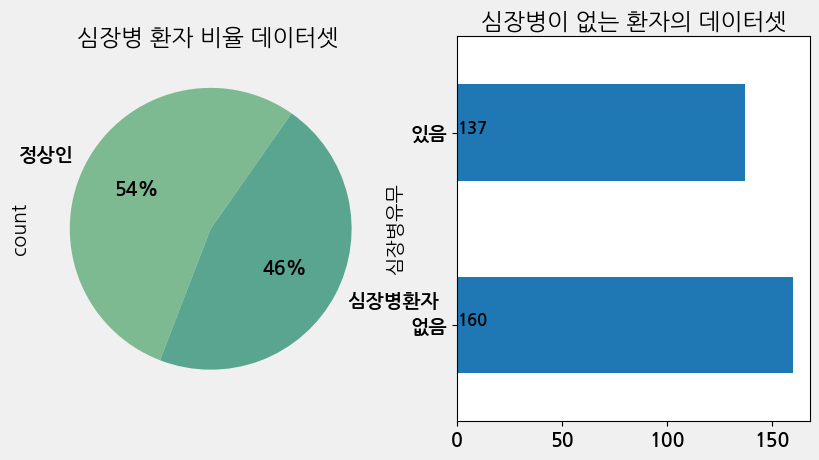

In [179]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=(10,5), facecolor=(.94, .94, .94))

ax1 = df4['심장병유무'].value_counts().plot.pie(
    x='심장병', y='no.of patients',
    autopct='%1.0f%%', labels=['정상인', '심장병환자'],
    startangle=55, ax=ax1, colors=sns.color_palette('crest'))
ax1.set(title='심장병 환자 비율 데이터셋 ')

ax2 = df4['심장병유무'].value_counts().plot(kind='barh', ax=ax2)
for x, y in enumerate(df4['심장병유무'].value_counts().values):
    ax2.text(.5, x, y, fontsize=12)
ax2.set(title='심장병이 없는 환자의 데이터셋')
plt.show()

##  Gender and Agewise Distribution 성별 및 연령별 분포

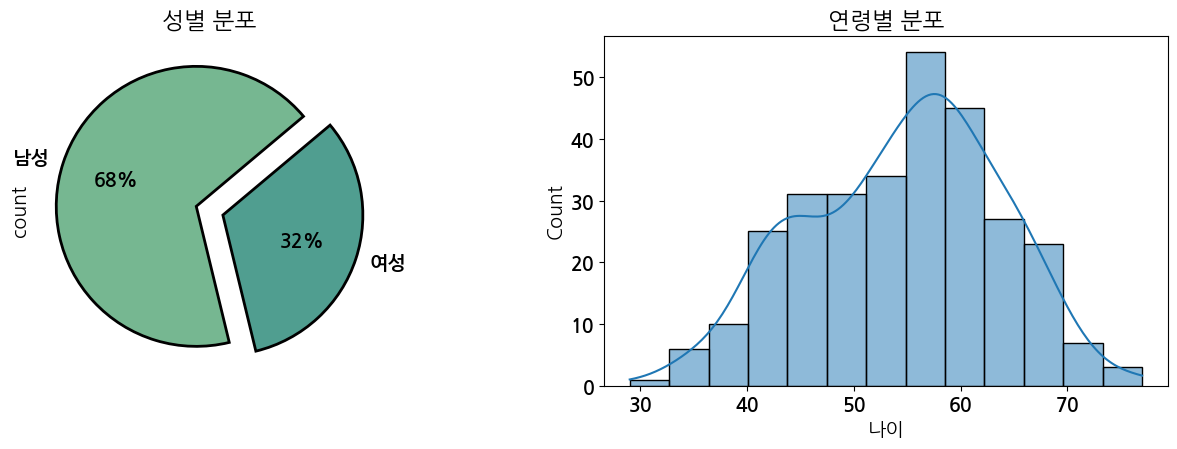

In [180]:
plt.figure(figsize=(16,10))
plt.subplot(221)
df1['성별'].value_counts().plot.pie(
    autopct='%1.0f%%', colors=sns.color_palette('crest', 5),
    startangle=40, labels=['남성', '여성'],
    wedgeprops={'linewidth':2, 'edgecolor':'k'},
    explode=[.1, .1], shadow=False)
plt.title('성별 분포')
plt.subplot(222)
ax = sns.histplot(df1['나이'], kde=True)
plt.title('연령별 분포')
plt.show()

As we can see from above plot, in this dataset males percentage is way too higher than females where as average age of patients is around 60.

# 환자별 연령분포

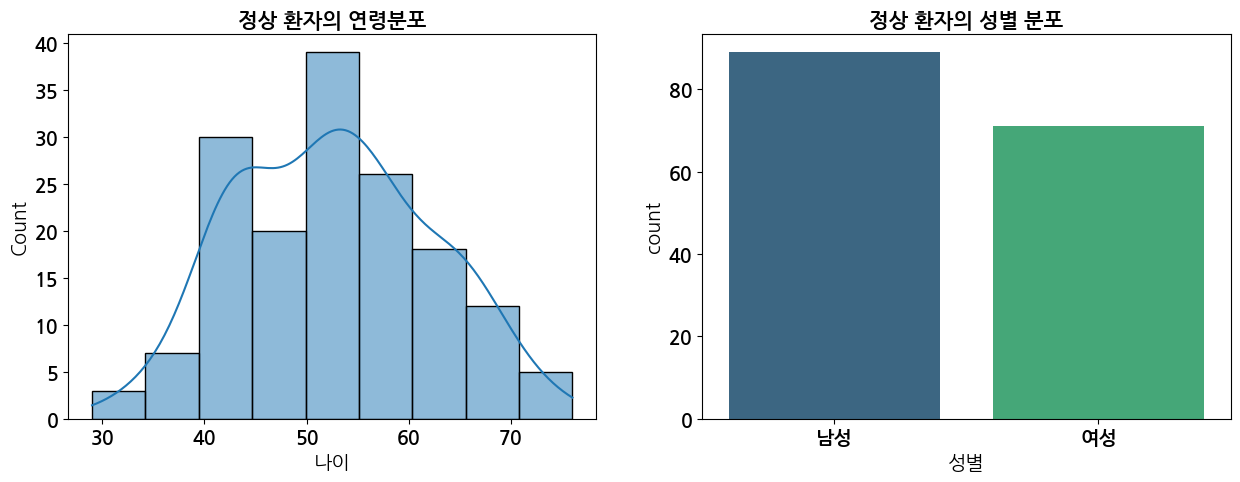

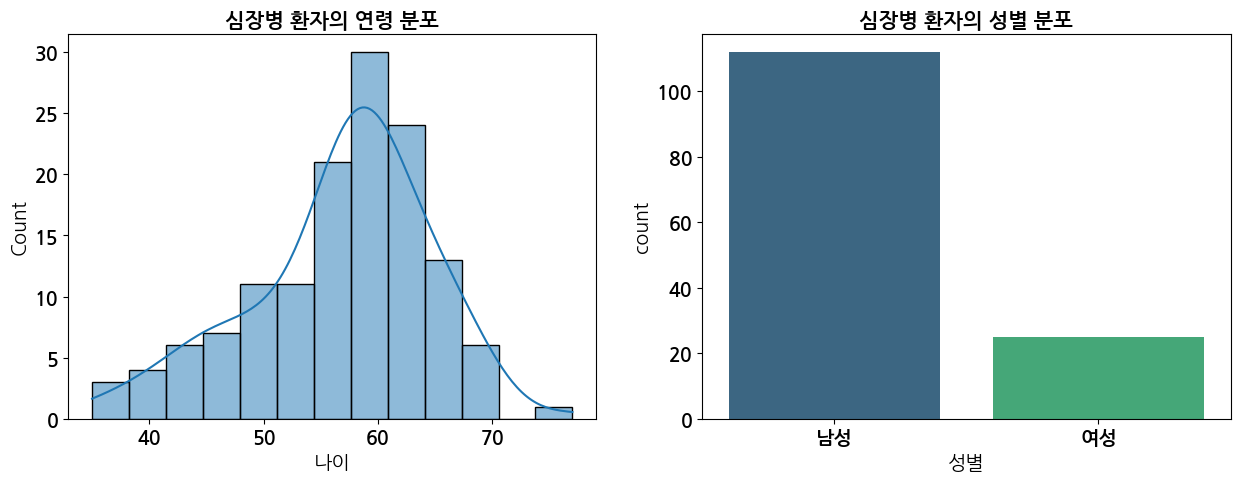

In [181]:
df_1 = df1[df1['심장병유무'] == 1]
df_0 = df1[df1['심장병유무'] == 0]

# plotting normal patients
fig = plt.figure(figsize=(15, 5))
ax1 = plt.subplot2grid((1,2), (0,0))
sns.histplot(df_0['나이'], kde=True)
plt.title('정상 환자의 연령분포', fontsize=15, weight='bold')

ax1 = plt.subplot2grid((1,2), (0,1))
# palette without hue deprecated in seaborn 0.13 / error in 0.14 → hue 추가
sns.countplot(x=df_0['성별'], hue=df_0['성별'], palette='viridis', legend=False)
plt.title('정상 환자의 성별 분포', fontsize=15, weight='bold')
plt.show()

# plotting heart patients
fig = plt.figure(figsize=(15, 5))
ax1 = plt.subplot2grid((1,2), (0,0))
sns.histplot(df_1['나이'], kde=True)
plt.title('심장병 환자의 연령 분포', fontsize=15, weight='bold')

ax1 = plt.subplot2grid((1,2), (0,1))
sns.countplot(x=df_1['성별'], hue=df_1['성별'], palette='viridis', legend=False)
plt.title('심장병 환자의 성별 분포', fontsize=15, weight='bold')
plt.show()

# Distribution of Chest Pain Type 흉통 유형의 분포

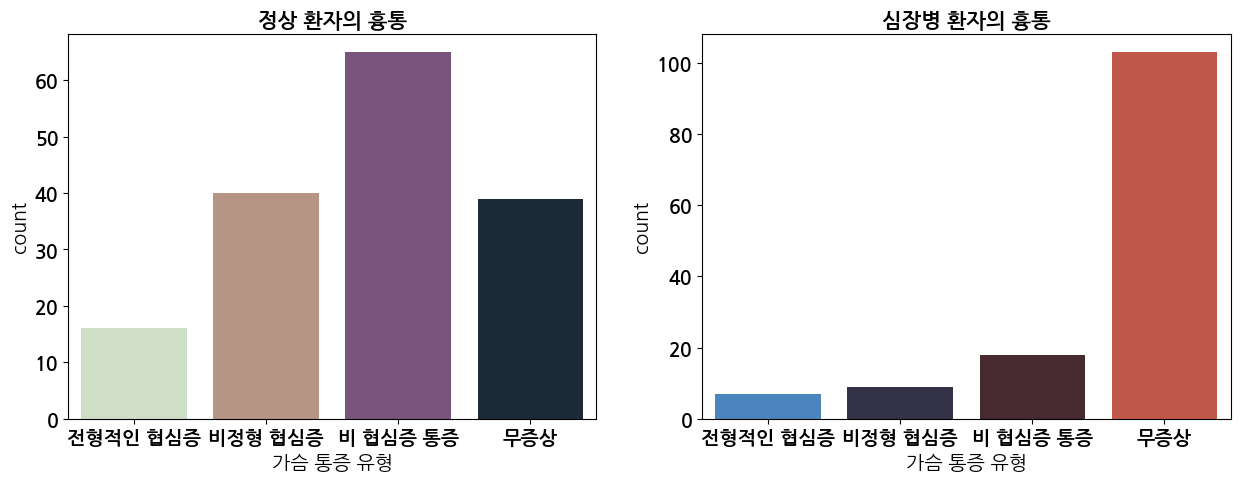

In [182]:
fig = plt.figure(figsize=(15, 5))
ax1 = plt.subplot2grid((1,2), (0,0))
sns.countplot(x=df_0['가슴 통증 유형'], hue=df_0['가슴 통증 유형'],
              palette='ch:start=4.2,rot=-3.3', legend=False)
plt.title('정상 환자의 흉통', fontsize=15, weight='bold')

ax1 = plt.subplot2grid((1,2), (0,1))
sns.countplot(x=df_1['가슴 통증 유형'], hue=df_1['가슴 통증 유형'],
              palette='icefire', legend=False)
plt.title('심장병 환자의 흉통', fontsize=15, weight='bold')
plt.show()

In [183]:
plot_criteria = ['가슴 통증 유형', '심장병유무']
cm = sns.light_palette('green', as_cmap=True)
(round(pd.crosstab(df4[plot_criteria[0]], df4[plot_criteria[1]], normalize='columns') * 100, 2)).style.background_gradient(cmap=cm)

심장병유무,없음,있음
가슴 통증 유형,,
무증상,24.380000,75.180000
비 협심증 통증,40.620000,13.140000
비정형 협심증,25.000000,6.570000
전형적인 협심증,10.000000,5.110000


As we can see from above plot 41% of the chest pain type of the heart disease patients have non-aginal chest pain

# Distribution of Rest ECG 심장통에 따른 휴식 심전도 분포

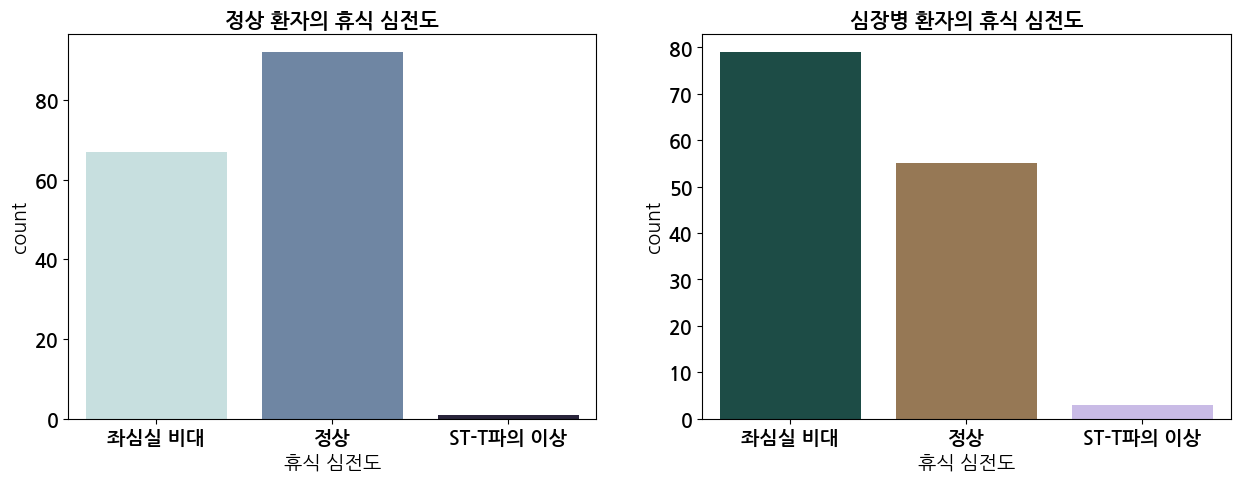

In [184]:
fig = plt.figure(figsize=(15, 5))
ax1 = plt.subplot2grid((1,2), (0,0))
sns.countplot(x=df_0['휴식 심전도'], hue=df_0['휴식 심전도'],
              palette='ch:start=.2,rot=-.3', legend=False)
plt.title('정상 환자의 휴식 심전도', fontsize=15, weight='bold')

ax1 = plt.subplot2grid((1,2), (0,1))
sns.countplot(x=df_1['휴식 심전도'], hue=df_1['휴식 심전도'],
              palette='cubehelix', legend=False)
plt.title('심장병 환자의 휴식 심전도', fontsize=15, weight='bold')
plt.show()

In [185]:
plot_criteria = ['휴식 심전도', '심장병유무']
cm = sns.light_palette('white', as_cmap=True)
(round(pd.crosstab(df4[plot_criteria[0]], df4[plot_criteria[1]], normalize='columns') * 100, 2)).style.background_gradient(cmap=cm)

심장병유무,없음,있음
휴식 심전도,,
ST-T파의 이상,0.620000,2.190000
정상,57.500000,40.150000
좌심실 비대,41.880000,57.660000


# ST Slope에 따른 심장통증

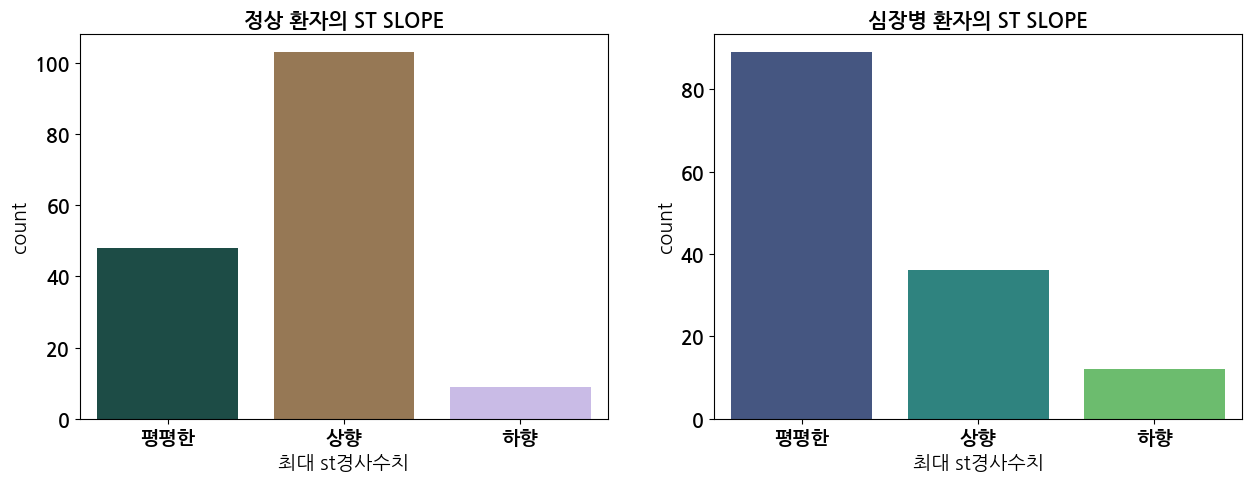

In [186]:
fig = plt.figure(figsize=(15, 5))
ax1 = plt.subplot2grid((1,2), (0,0))
sns.countplot(x=df_0['최대 st경사수치'], hue=df_0['최대 st경사수치'],
              palette='cubehelix', legend=False)
plt.title('정상 환자의 ST SLOPE', fontsize=15, weight='bold')

ax1 = plt.subplot2grid((1,2), (0,1))
sns.countplot(x=df_1['최대 st경사수치'], hue=df_1['최대 st경사수치'],
              palette='viridis', legend=False)
plt.title('심장병 환자의 ST SLOPE', fontsize=15, weight='bold')
plt.show()

In [187]:
plot_criteria = ['최대 st경사수치', '심장병유무']
cm = sns.light_palette('green', as_cmap=True)
(round(pd.crosstab(df4[plot_criteria[0]], df4[plot_criteria[1]], normalize='columns') * 100, 2)).style.background_gradient(cmap=cm)

심장병유무,없음,있음
최대 st경사수치,,
상향,64.380000,26.280000
평평한,30.000000,64.960000
하향,5.620000,8.760000


# 지중해빈혈에 따른 심장통증 빈도

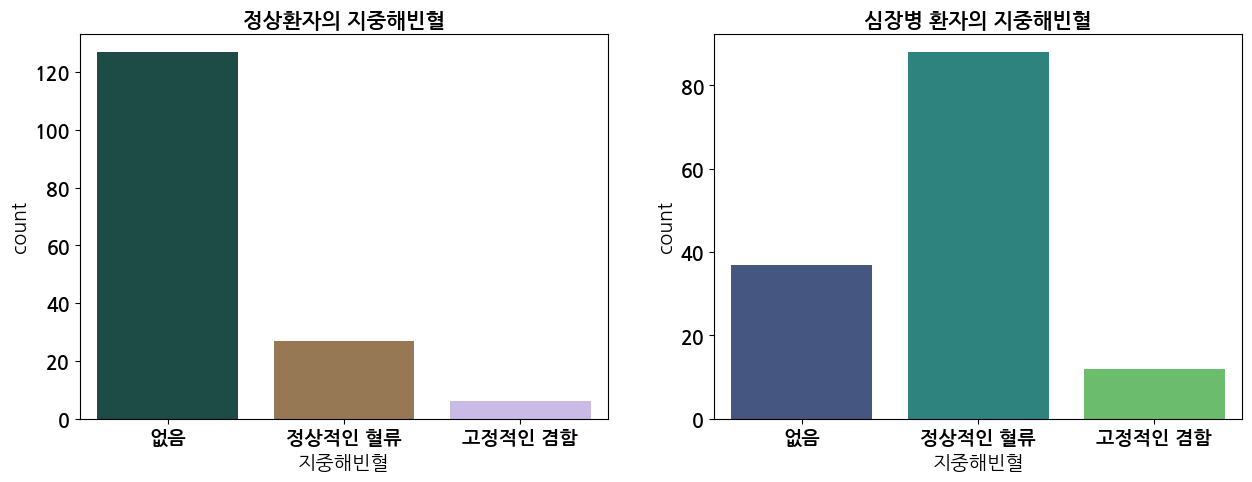

In [188]:
fig = plt.figure(figsize=(15, 5))
ax1 = plt.subplot2grid((1,2), (0,0))
sns.countplot(x=df_0['지중해빈혈'], hue=df_0['지중해빈혈'],
              palette='cubehelix', legend=False)
plt.title('정상환자의 지중해빈혈', fontsize=15, weight='bold')

ax1 = plt.subplot2grid((1,2), (0,1))
sns.countplot(x=df_1['지중해빈혈'], hue=df_1['지중해빈혈'],
              palette='viridis', legend=False)
plt.title('심장병 환자의 지중해빈혈', fontsize=15, weight='bold')
plt.show()

In [189]:
plot_criteria = ['지중해빈혈', '심장병유무']
cm = sns.light_palette('green', as_cmap=True)
(round(pd.crosstab(df4[plot_criteria[0]], df4[plot_criteria[1]], normalize='columns') * 100, 2)).style.background_gradient(cmap=cm)

심장병유무,없음,있음
지중해빈혈,,
고정적인 겸함,3.750000,8.760000
없음,79.380000,27.010000
정상적인 혈류,16.880000,64.230000


# Distribution of Numerical features 수치적 특징의 분포

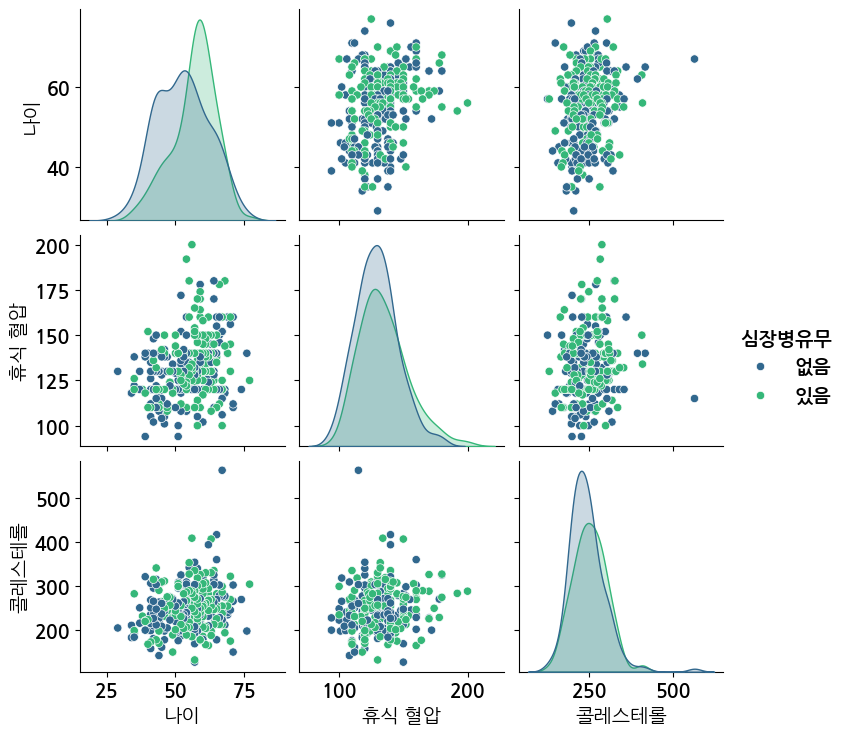

In [190]:
sns.pairplot(df4, hue='심장병유무', vars=['나이', '휴식 혈압', '콜레스테롤'], palette='viridis')

From the above plotdistribution we can say that as the age increases chances of heart disease increases

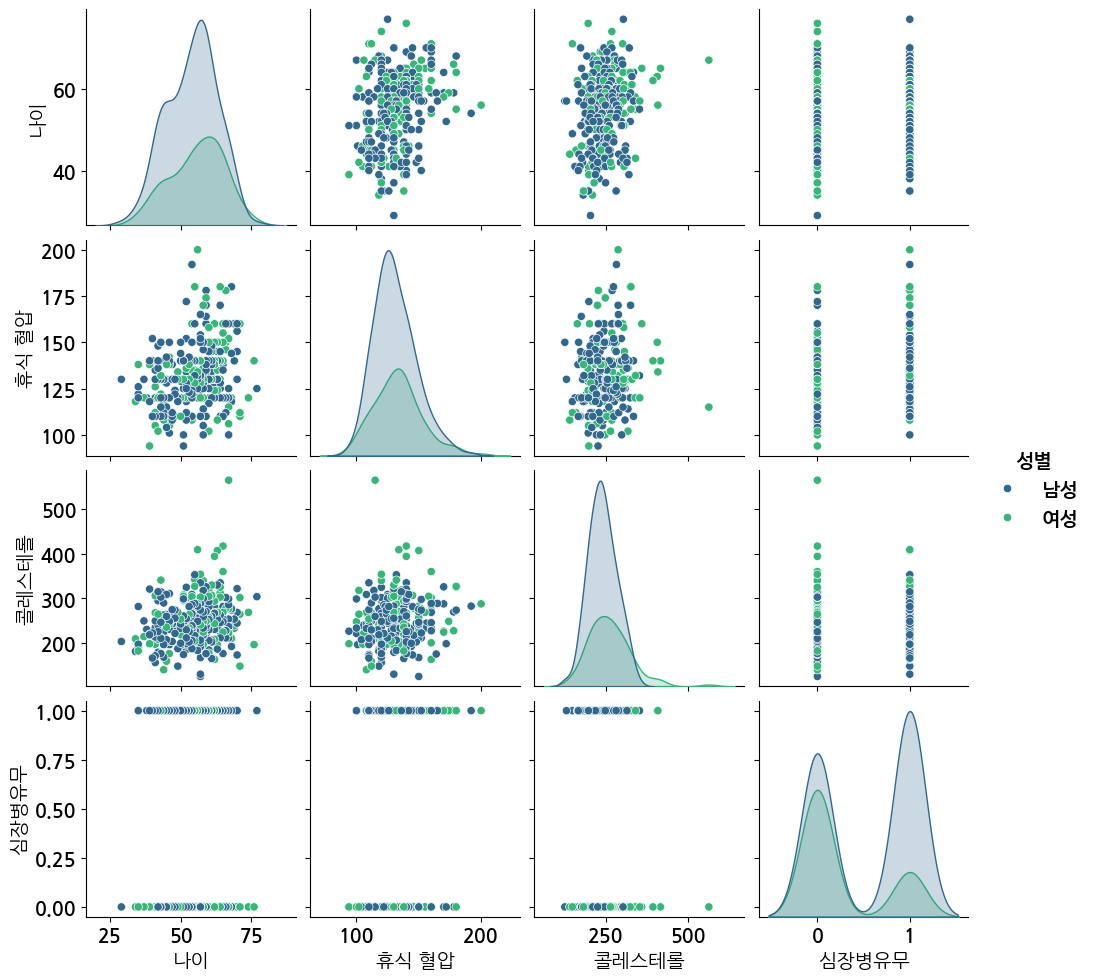

In [191]:
sns.pairplot(df1, hue='성별', vars=['나이', '휴식 혈압', '콜레스테롤', '심장병유무'], palette='viridis')

# 통계적 유의성 검증 (Statistical Significance Tests)

In [192]:
from scipy.stats import mannwhitneyu, chi2_contingency

df_heart = df1[df1['심장병유무'] == 1]
df_normal = df1[df1['심장병유무'] == 0]

# 연속형 변수: Mann-Whitney U test (정규성 가정 없이 두 그룹 차이 검정)
print('=' * 55)
print('연속형 변수 Mann-Whitney U test (심장병 유무 그룹 비교)')
print('=' * 55)
continuous_vars = ['나이', '콜레스테롤', '휴식 혈압', '최대 심박수 달성']
for var in continuous_vars:
    stat, p = mannwhitneyu(df_heart[var].dropna(),
                           df_normal[var].dropna(),
                           alternative='two-sided')
    sig = '*** 유의함 (p < 0.05)' if p < 0.05 else '유의하지 않음'
    print(f'{var:15s}: p = {p:.4f}  →  {sig}')

# 범주형 변수: Chi-square test
print()
print('=' * 55)
print('범주형 변수 Chi-square test (심장병 유무 그룹 비교)')
print('=' * 55)
cat_vars = ['가슴 통증 유형', '휴식 심전도', '최대 st경사수치', '지중해빈혈']
for var in cat_vars:
    ct = pd.crosstab(df1[var], df1['심장병유무'])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = '*** 유의함 (p < 0.05)' if p < 0.05 else '유의하지 않음'
    print(f'{var:15s}: chi2 = {chi2:.3f}, p = {p:.4f}  →  {sig}')

연속형 변수 Mann-Whitney U test (심장병 유무 그룹 비교)
나이             : p = 0.0000  →  *** 유의함 (p < 0.05)
콜레스테롤          : p = 0.0467  →  *** 유의함 (p < 0.05)
휴식 혈압          : p = 0.0235  →  *** 유의함 (p < 0.05)
최대 심박수 달성      : p = 0.0000  →  *** 유의함 (p < 0.05)

범주형 변수 Chi-square test (심장병 유무 그룹 비교)
가슴 통증 유형       : chi2 = 77.276, p = 0.0000  →  *** 유의함 (p < 0.05)
휴식 심전도         : chi2 = 9.576, p = 0.0083  →  *** 유의함 (p < 0.05)
최대 st경사수치      : chi2 = 43.473, p = 0.0000  →  *** 유의함 (p < 0.05)
지중해빈혈          : chi2 = 82.460, p = 0.0000  →  *** 유의함 (p < 0.05)


In [193]:
#sns.scatterplot(x='휴식 혈압', y='콜레스테롤', hue='심장병유무', data=df4)

In [194]:
#sns.scatterplot(x='휴식 혈압', y='나이', hue='심장병유무', data=df4)

# 특징 간 상관관계 분석 (Correlation Heatmap)

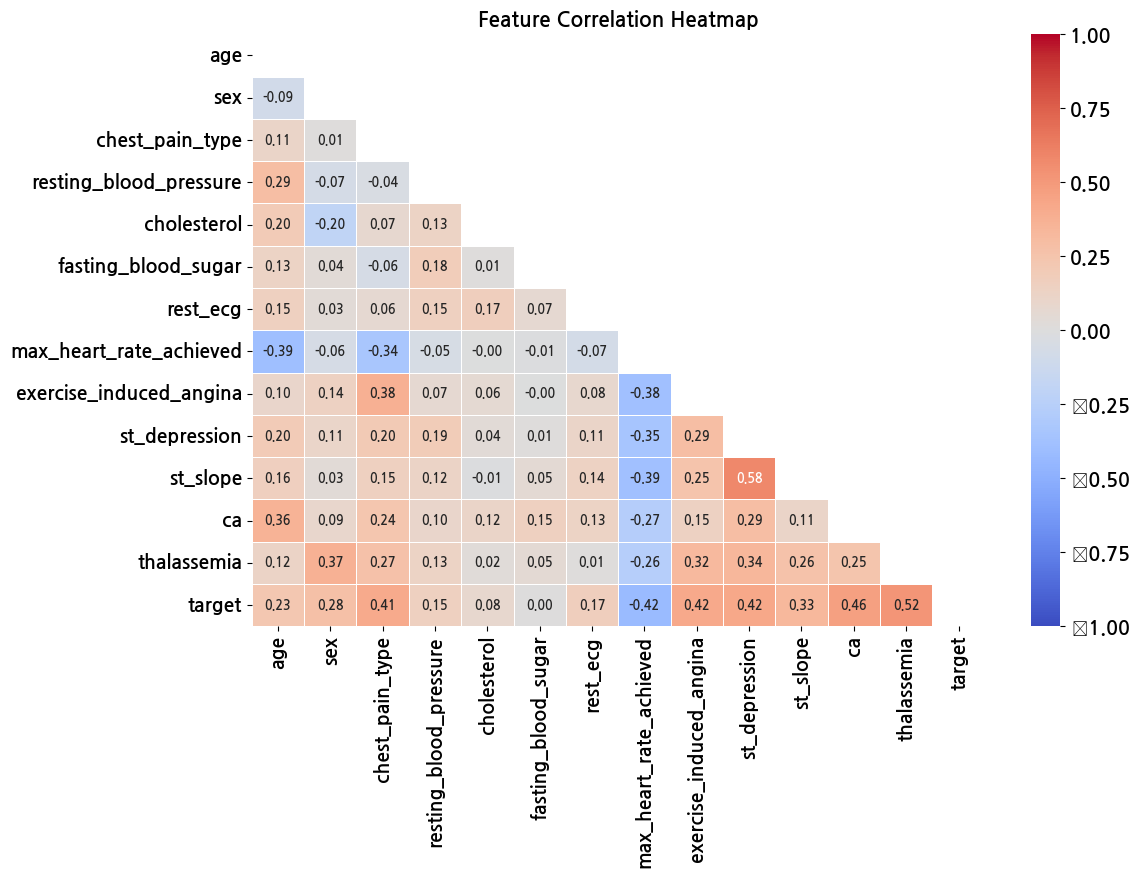

In [195]:
plt.figure(figsize=(12, 9))
corr = df[df.columns].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, vmin=-1, vmax=1, center=0,
    annot_kws={'size': 9}
)
plt.title('Feature Correlation Heatmap', fontsize=15, weight='bold')
plt.tight_layout()
plt.show()

# 연속형 특징의 심장병 유무별 분포 (Box Plot)

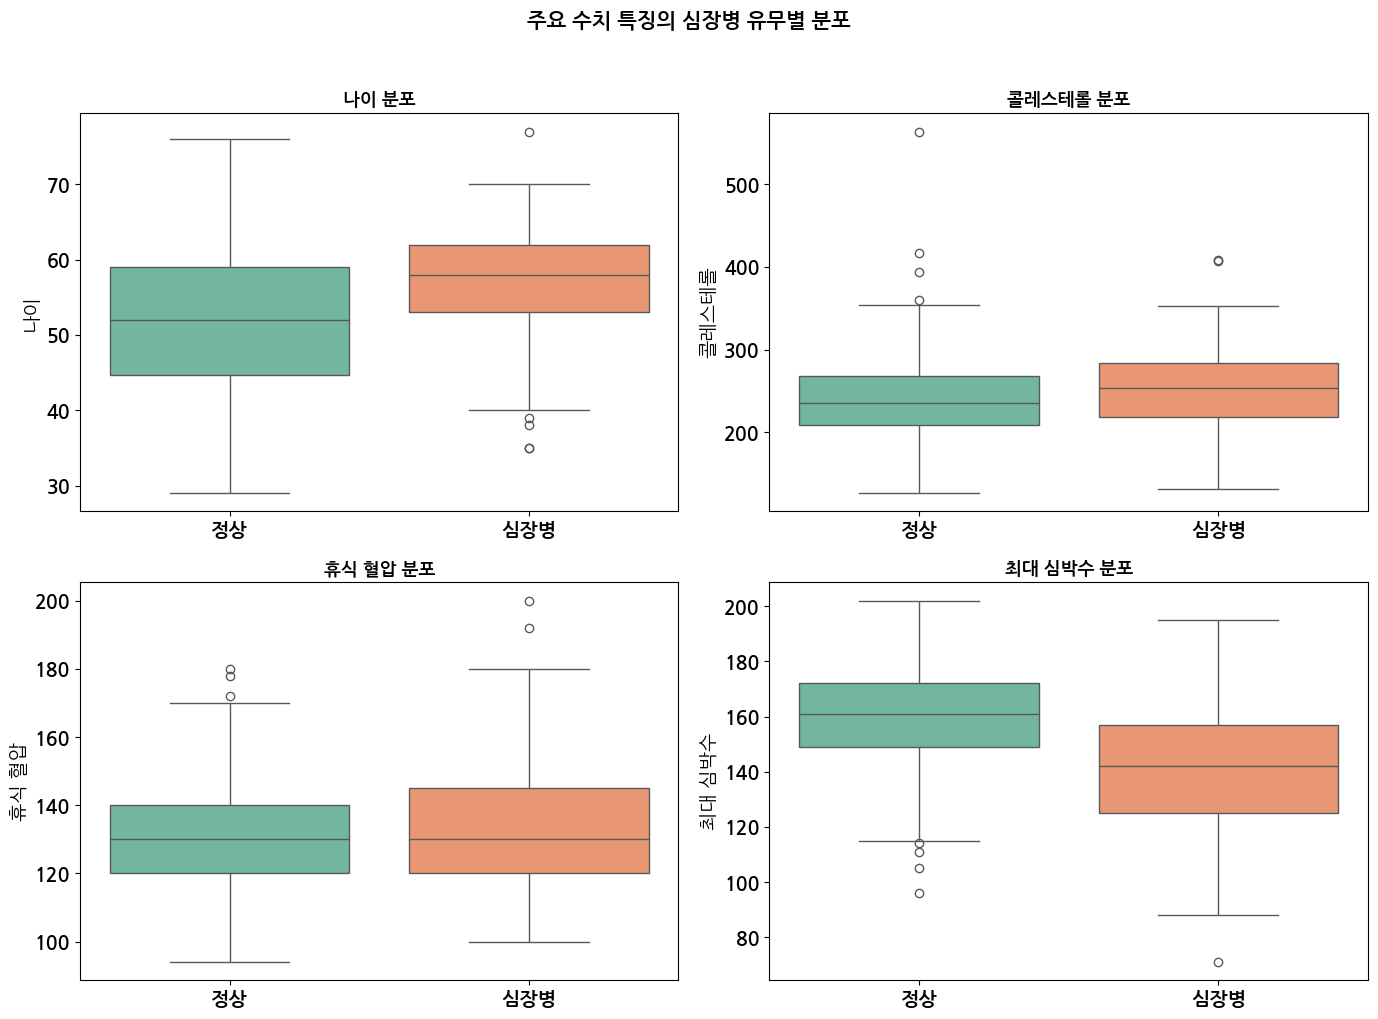

In [196]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
box_features = [
    ('age', '나이'),
    ('cholesterol', '콜레스테롤'),
    ('resting_blood_pressure', '휴식 혈압'),
    ('max_heart_rate_achieved', '최대 심박수')
]
for ax, (col, label) in zip(axes.flatten(), box_features):
    df_plot = df.copy()
    df_plot['심장병유무'] = df_plot['target'].map({0: '정상', 1: '심장병'})
    # palette without hue deprecated in seaborn 0.13 / error in 0.14 → hue 추가
    sns.boxplot(x='심장병유무', y=col, data=df_plot,
                hue='심장병유무', palette='Set2', legend=False, ax=ax)
    ax.set_title(f'{label} 분포', fontsize=13, weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(label)
plt.suptitle('주요 수치 특징의 심장병 유무별 분포', fontsize=15, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 여기서부터 모델 만들기

In [197]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,ca,thalassemia,target
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [198]:
X = df.drop(['target'], axis=1)
y = df['target']
feature_name = X.columns

In [199]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (log_loss, roc_auc_score, precision_score,
                              f1_score, recall_score, roc_curve, auc)
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, fbeta_score, matthews_corrcoef)
from sklearn import metrics
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn import model_selection
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=22
)

# val_x, val_y 미사용으로 X_train을 불필요하게 축소함 → 주석 처리
# X_train, val_x, y_train, val_y = train_test_split(
#     X_train, y_train, test_size=0.2, random_state=22
# )

In [200]:
# (전체 데이터셋수, 컬럼), (학습 데이터, 컬럼), (테스트 데이터, 컬럼)
print(X.shape, X_train.shape, X_test.shape)

(297, 13) (237, 13) (60, 13)


In [201]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
num_cols = ['age', 'resting_blood_pressure', 'cholesterol',
            'max_heart_rate_achieved', 'st_depression']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_train.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,ca,thalassemia
151,0.116279,1,2,0.433962,0.445205,0,2,0.895161,0,0.000000,0,0,0
46,0.418605,1,1,0.245283,0.454338,0,0,0.814516,0,0.032258,0,0,0
167,0.744186,0,3,0.792453,0.232877,1,0,0.758065,1,0.161290,1,2,2
169,0.744186,1,3,0.622642,0.232877,0,2,0.540323,0,0.370968,0,0,1
130,0.325581,0,2,0.339623,0.340183,0,0,0.548387,0,0.032258,0,0,0


In [202]:
X_test[num_cols] = scaler.transform(X_test[num_cols])
X_test.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,ca,thalassemia
207,0.581395,1,3,0.386792,0.246575,0,0,0.725806,0,0.080645,1,0,2
114,0.441860,1,2,0.339623,0.162100,1,2,0.653226,0,0.193548,2,0,0
101,0.558140,0,2,0.245283,0.488584,0,0,0.814516,0,0.000000,0,0,0
26,0.744186,1,1,0.622642,0.273973,0,0,0.395161,1,0.000000,1,3,1
71,-0.116279,1,1,0.339623,0.178082,0,2,1.056452,0,0.000000,0,0,0


# 최적의 k값을 찾기 위한 함수 간략하게 설명하고 가도 될 것 같습니다!

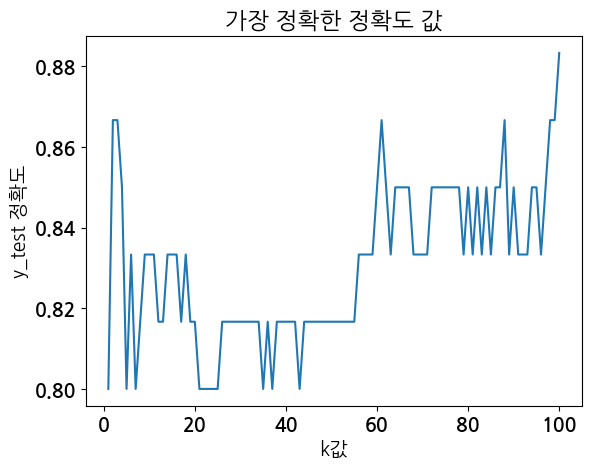

최적의 k 값: 100
가장 높은 정확도: 0.8833333333333333


In [203]:
k_list = range(1, 101)
accuracies = []
best_k = None
best_accuracy = 0.0

for k in k_list:
    classifier = KNeighborsClassifier(n_neighbors=k)
    classifier.fit(X_train, y_train)
    accuracy = classifier.score(X_test, y_test)
    accuracies.append(accuracy)
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_k = k

plt.plot(k_list, accuracies)
plt.xlabel('k값')
plt.ylabel('y_test 정확도')
plt.title('가장 정확한 정확도 값')
plt.show()

print('최적의 k 값:', best_k)
print('가장 높은 정확도:', best_accuracy)

In [204]:
# n_neighbors=4 하드코딩 → best_k 변수 사용
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

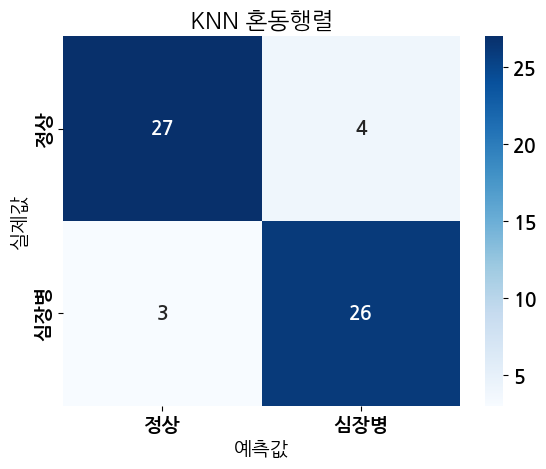

,Model,Accuracy,recall,Precision,Sensitivity,Specificity,F1 Score,ROC,Log_Loss,mathew_corrcoef
0,KNN,0.883333,0.896552,0.866667,0.896552,0.870968,0.881356,0.88376,4.205093,0.767093


In [205]:
CM = confusion_matrix(y_test, y_pred_knn)
# fmt='d': 정수 표시 / xticklabels, yticklabels: 레이블 추가 / cmap: 색상
sns.heatmap(CM, annot=True, fmt='d', cmap='Blues',
            xticklabels=['정상', '심장병'], yticklabels=['정상', '심장병'])
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.title('KNN 혼동행렬')
plt.show()

TN = CM[0][0]; FN = CM[1][0]; TP = CM[1][1]; FP = CM[0][1]
specificity = TN / (TN + FP)
recall = TP / (TP + FN)

loss_log = log_loss(y_test, y_pred_knn)
acc = accuracy_score(y_test, y_pred_knn)
roc = roc_auc_score(y_test, y_pred_knn)
prec = precision_score(y_test, y_pred_knn)
rec = recall_score(y_test, y_pred_knn)
f1 = f1_score(y_test, y_pred_knn)
mathew = matthews_corrcoef(y_test, y_pred_knn)

model_results = pd.DataFrame(
    [['KNN', acc, rec, prec, rec, specificity, f1, roc, loss_log, mathew]],
    columns=['Model', 'Accuracy', 'recall', 'Precision',
             'Sensitivity', 'Specificity', 'F1 Score', 'ROC', 'Log_Loss', 'mathew_corrcoef']
)
model_results

# 이 부분도 그래프와 수치들을 보여주면서 설명해주세요!
## 각 함수마다 random_state, 은닉층, 활성화 함수를 구해서 마지막에 학습시키는 파트라
## 함수 넘어가는 과정마다
## model = MLPClassifier(solver='adam', random_state=random_state)
## 이 부분을 수정하면서 최적 값을 구했다는 걸 중점으로 설명해주세요!

Random State: 10, Test Accuracy: 0.8333333333333334
Random State: 20, Test Accuracy: 0.8833333333333333
Random State: 30, Test Accuracy: 0.8666666666666667
Random State: 40, Test Accuracy: 0.85
Random State: 50, Test Accuracy: 0.85
Random State: 60, Test Accuracy: 0.8833333333333333
Random State: 70, Test Accuracy: 0.85
Random State: 80, Test Accuracy: 0.75
Random State: 90, Test Accuracy: 0.8666666666666667
Random State: 100, Test Accuracy: 0.7166666666666667
최적의 Random State: 20


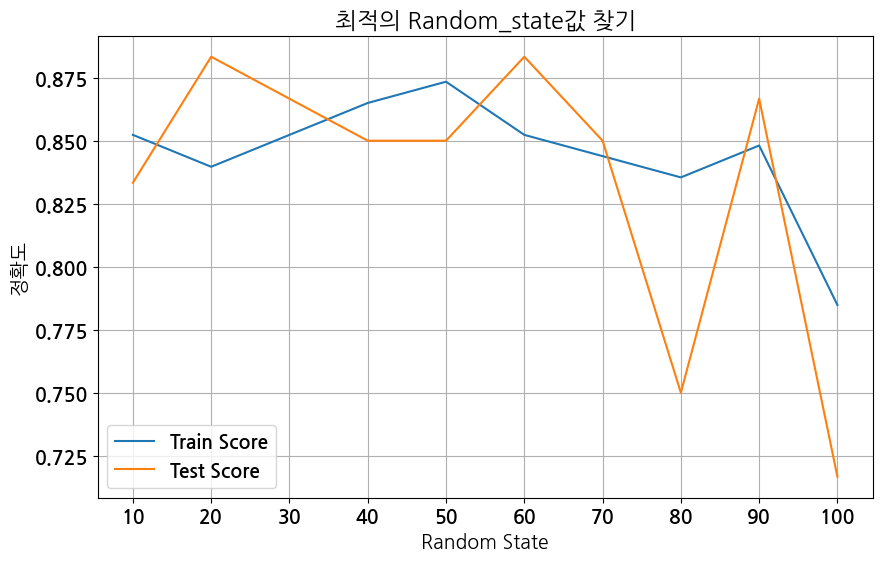

In [206]:
random_state_start = 10
random_state_end = 100
random_state_step = 10
random_state_values = list(range(random_state_start, random_state_end + 1, random_state_step))

train_scores = []
test_scores = []
best_random_state = None
best_score = 0.0

# 데이터 분할 고정 (random_state=22), MLP 초기화 random_state만 탐색
# X_train, X_test를 덮어쓰지 않도록 임시 변수 사용
X_tr_tmp, X_te_tmp, y_tr_tmp, y_te_tmp = train_test_split(
    X, y, test_size=0.2, random_state=22
)

for random_state in random_state_values:
    model = MLPClassifier(solver='adam', random_state=random_state)
    model.fit(X_tr_tmp, y_tr_tmp)
    train_score = model.score(X_tr_tmp, y_tr_tmp)
    test_score = model.score(X_te_tmp, y_te_tmp)
    train_scores.append(train_score)
    test_scores.append(test_score)
    if test_score > best_score:
        best_random_state = random_state
        best_score = test_score
    print(f'Random State: {random_state}, Test Accuracy: {test_score}')

print('최적의 Random State:', best_random_state)

x = np.arange(len(random_state_values))
plt.figure(figsize=(10, 6))
plt.plot(x, train_scores, label='Train Score')
plt.plot(x, test_scores, label='Test Score')
plt.xticks(x, random_state_values)
plt.xlabel('Random State')
plt.ylabel('정확도')
plt.title('최적의 Random_state값 찾기')
plt.legend()
plt.grid(True)
plt.show()

Best Hidden Layer Sizes: (30, 30)
Best Accuracy: 0.8666666666666667


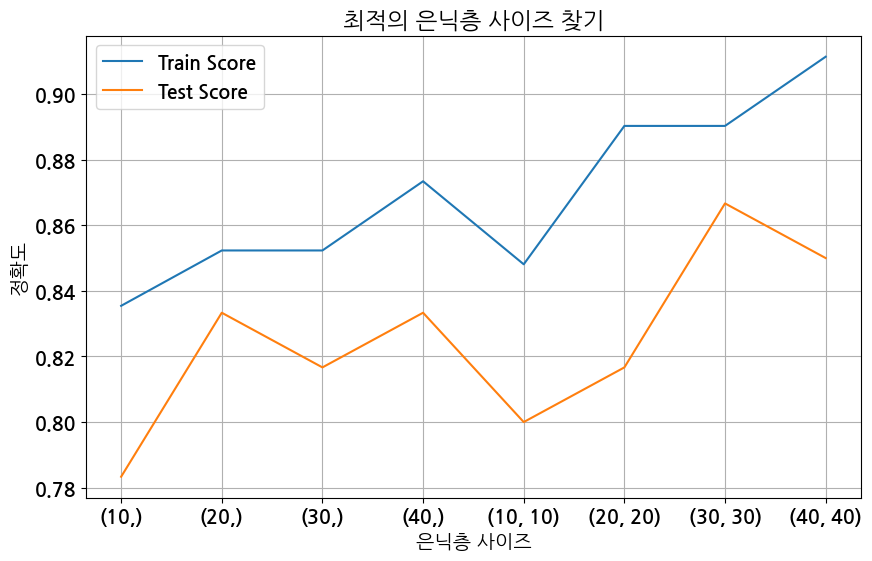

In [207]:
hidden_layer_sizes_values = [(10,), (20,), (30,), (40,)]
hidden_layer_sizes_values += [(i, i) for i in range(10, 41, 10)]

train_scores = []; test_scores = []
best_hidden_layer_sizes = None; best_score = 0.0

for hidden_layer_sizes in hidden_layer_sizes_values:
    model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, solver='adam', random_state=30)
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    train_scores.append(train_score)
    test_scores.append(test_score)
    if test_score > best_score:
        best_hidden_layer_sizes = hidden_layer_sizes
        best_score = test_score

print('Best Hidden Layer Sizes:', best_hidden_layer_sizes)
print('Best Accuracy:', best_score)

x = np.arange(len(hidden_layer_sizes_values))
plt.figure(figsize=(10, 6))
plt.plot(x, train_scores, label='Train Score')
plt.plot(x, test_scores, label='Test Score')
plt.xticks(x, hidden_layer_sizes_values)
plt.xlabel('은닉층 사이즈')
plt.ylabel('정확도')
plt.title('최적의 은닉층 사이즈 찾기')
plt.legend(); plt.grid(True); plt.show()

Best Max Iterations: 400
Best Accuracy: 0.85


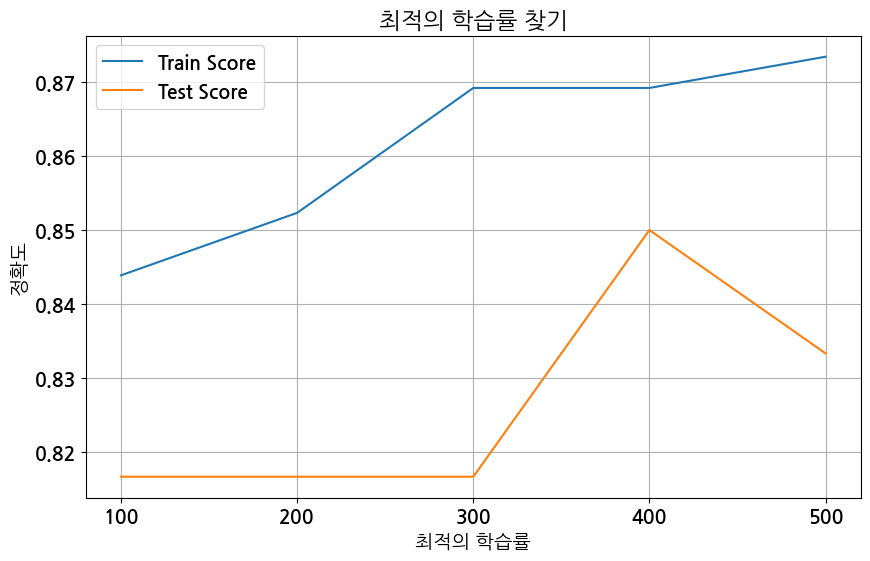

In [208]:
max_iter_values = [100, 200, 300, 400, 500]

train_scores = []; test_scores = []
best_max_iter = None; best_score = 0.0

for max_iter in max_iter_values:
    model = MLPClassifier(hidden_layer_sizes=(30,), solver='adam',
                          max_iter=max_iter, random_state=30)
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    train_scores.append(train_score)
    test_scores.append(test_score)
    if test_score > best_score:
        best_max_iter = max_iter
        best_score = test_score

print('Best Max Iterations:', best_max_iter)
print('Best Accuracy:', best_score)

x = np.arange(len(max_iter_values))
plt.figure(figsize=(10, 6))
plt.plot(x, train_scores, label='Train Score')
plt.plot(x, test_scores, label='Test Score')
plt.xticks(x, max_iter_values)
plt.xlabel('최적의 학습률')
plt.ylabel('정확도')
plt.title('최적의 학습률 찾기')
plt.legend(); plt.grid(True); plt.show()

활성화 함수: identity, Test 정확도: 0.8166666666666667
활성화 함수: relu, Test 정확도: 0.8166666666666667
활성화 함수: logistic, Test 정확도: 0.8333333333333334
활성화 함수: tanh, Test 정확도: 0.8166666666666667
최적의 활성화 함수: logistic


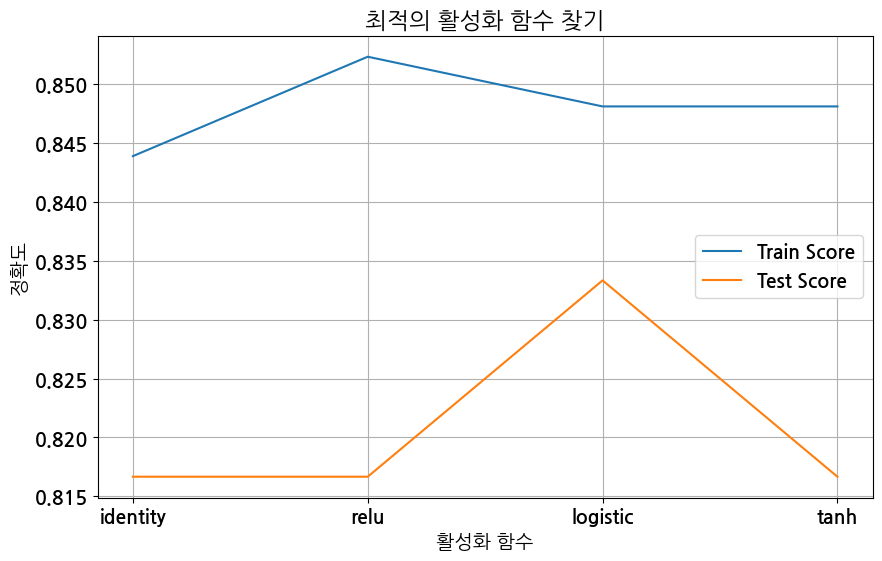

In [209]:
activation_values = ['identity', 'relu', 'logistic', 'tanh']

train_scores = []; test_scores = []
best_activation = None; best_score = 0.0

for activation in activation_values:
    model = MLPClassifier(hidden_layer_sizes=(30,), activation=activation,
                          max_iter=200, solver='adam', random_state=30)
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    train_scores.append(train_score)
    test_scores.append(test_score)
    if test_score > best_score:
        best_activation = activation
        best_score = test_score
    print(f'활성화 함수: {activation}, Test 정확도: {test_score}')

print('최적의 활성화 함수:', best_activation)

x = np.arange(len(activation_values))
plt.figure(figsize=(10, 6))
plt.plot(x, train_scores, label='Train Score')
plt.plot(x, test_scores, label='Test Score')
plt.xticks(x, activation_values)
plt.xlabel('활성화 함수')
plt.ylabel('정확도')
plt.title('최적의 활성화 함수 찾기')
plt.legend(); plt.grid(True); plt.show()

# 이 파트는 위에서 최적값 구한걸 학습시킨 모델을 정의한 부분입니다!

In [210]:
mlp = MLPClassifier(hidden_layer_sizes=(30,), activation='relu',
                    solver='adam', max_iter=100, random_state=30)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

# 함수파트는 발표시간 부족할 것 같으면 해주시고 아니면 간략하게 설명해주세요!

In [211]:
def modeling_uncustomized(algorithm, x_train, y_train, x_test, y_test):
    uncustomized = algorithm(random_state=22)
    uncustomized.fit(x_train, y_train)
    train_score_before = round(uncustomized.score(x_train, y_train), 3)
    print(f'학습 데이터셋 정확도: {train_score_before}')
    test_score_before = round(uncustomized.score(x_test, y_test), 3)
    print(f'테스트 데이터셋 정확도: {test_score_before}')
    return train_score_before, test_score_before

In [212]:
def optimi_visualization(algorithm_name, x_values, train_score, test_score, xlabel, filename):
    plt.plot(x_values, train_score, linestyle='-', label='train score')
    plt.plot(x_values, test_score, linestyle='--', label='test score')
    plt.ylabel('Accuracy(%)')
    plt.xlabel(xlabel)
    plt.legend()

In [213]:
def optimi_estimator(algorithm, algorithm_name, x_train, y_train, x_test, y_test,
                     n_estimator_min, n_estimator_max):
    train_score = []; test_score = []
    para_n_tree = [n_tree * 5 for n_tree in range(n_estimator_min, n_estimator_max)]
    for v_n_estimators in para_n_tree:
        model = algorithm(n_estimators=v_n_estimators, random_state=22)
        model.fit(x_train, y_train)
        train_score.append(model.score(x_train, y_train))
        test_score.append(model.score(x_test, y_test))
    df_score_n = pd.DataFrame({'n_estimators': para_n_tree,
                               'TrainScore': train_score, 'TestScore': test_score})
    optimi_visualization(algorithm_name, para_n_tree, train_score, test_score,
                         'The number of estimator', 'n_estimator')
    print(round(df_score_n, 4))

In [214]:
def optimi_maxdepth(algorithm, algorithm_name, x_train, y_train, x_test, y_test,
                    depth_min, depth_max, n_estimator):
    train_score = []; test_score = []
    para_depth = list(range(depth_min, depth_max))
    for v_max_depth in para_depth:
        if algorithm == DTC:
            model = algorithm(max_depth=v_max_depth, random_state=22)
        else:
            model = algorithm(max_depth=v_max_depth,
                              n_estimators=n_estimator, random_state=22)
        model.fit(x_train, y_train)
        train_score.append(model.score(x_train, y_train))
        test_score.append(model.score(x_test, y_test))
    df_score_n = pd.DataFrame({'depth': para_depth,
                               'TrainScore': train_score, 'TestScore': test_score})
    optimi_visualization(algorithm_name, para_depth, train_score, test_score,
                         'The number of depth', 'n_depth')
    print(round(df_score_n, 4))

In [215]:
def optimi_minsplit(algorithm, algorithm_name, x_train, y_train, x_test, y_test,
                    n_split_min, n_split_max, n_estimator, n_depth):
    train_score = []; test_score = []
    para_split = [n_split * 2 for n_split in range(n_split_min, n_split_max)]
    for v_min_samples_split in para_split:
        if algorithm == DTC:
            model = algorithm(min_samples_split=v_min_samples_split,
                              max_depth=n_depth, random_state=22)
        else:
            model = algorithm(min_samples_split=v_min_samples_split,
                              n_estimators=n_estimator,
                              max_depth=n_depth, random_state=22)
        model.fit(x_train, y_train)
        train_score.append(model.score(x_train, y_train))
        test_score.append(model.score(x_test, y_test))
    df_score_n = pd.DataFrame({'min_samples_split': para_split,
                               'TrainScore': train_score, 'TestScore': test_score})
    optimi_visualization(algorithm_name, para_split, train_score, test_score,
                         'The minimum number of samples required to split an internal node',
                         'min_samples_split')
    print(round(df_score_n, 4))

In [216]:
def optimi_minleaf(algorithm, algorithm_name, x_train, y_train, x_test, y_test,
                   n_leaf_min, n_leaf_max, n_estimator, n_depth, n_split):
    train_score = []; test_score = []
    para_leaf = [n_leaf * 2 for n_leaf in range(n_leaf_min, n_leaf_max)]
    for v_min_samples_leaf in para_leaf:
        if algorithm == DTC:
            model = algorithm(min_samples_leaf=v_min_samples_leaf,
                              max_depth=n_depth, min_samples_split=n_split,
                              random_state=22)
        else:
            model = algorithm(min_samples_leaf=v_min_samples_leaf,
                              n_estimators=n_estimator, max_depth=n_depth,
                              min_samples_split=n_split, random_state=22)
        model.fit(x_train, y_train)
        train_score.append(model.score(x_train, y_train))
        test_score.append(model.score(x_test, y_test))
    df_score_n = pd.DataFrame({'min_samples_leaf': para_leaf,
                               'TrainScore': train_score, 'TestScore': test_score})
    optimi_visualization(algorithm_name, para_leaf, train_score, test_score,
                         'The minimum number of samples required to be at a leaf node',
                         'min_samples_leaf')
    print(round(df_score_n, 4))

In [217]:
def model_final(algorithm, algorithm_name, feature_name,
                x_train, y_train, x_test, y_test,
                n_estimator, n_depth, n_split, n_leaf):
    if algorithm == DTC:
        model = algorithm(random_state=22, min_samples_leaf=n_leaf,
                          min_samples_split=n_split, max_depth=n_depth)
    else:
        model = algorithm(random_state=22, n_estimators=n_estimator,
                          min_samples_leaf=n_leaf, min_samples_split=n_split,
                          max_depth=n_depth)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print(f'Accuracy:  {accuracy_score(y_test, y_pred):.3f}')
    print(f'Precision: {precision_score(y_test, y_pred):.3f}')
    print(f'Recall:    {recall_score(y_test, y_pred):.3f}')
    print(f'F1-score:  {f1_score(y_test, y_pred):.3f}')

    dt_importance = pd.DataFrame({
        'Feature': feature_name,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    print(dt_importance.round(3))
    dt_importance.sort_values('Importance', ascending=True, inplace=True)

    coordinates = range(len(dt_importance))
    plt.barh(y=coordinates, width=dt_importance['Importance'])
    plt.yticks(coordinates, dt_importance['Feature'])
    plt.xlabel('Feature Importance')
    plt.ylabel('Features')

# 70번까지 그래프와 수치(ex n_estimator=30)만 간략하게 보여주시면서 발표하시면 될 것 같습니다.

In [218]:
algorithm = RFC
algorithm_name = 'rfc'

In [219]:
train_acc_before, test_acc_before = modeling_uncustomized(
    algorithm, X_train, y_train, X_test, y_test)

학습 데이터셋 정확도: 1.0
테스트 데이터셋 정확도: 0.833


    n_estimators  TrainScore  TestScore
0              5      0.9916     0.8000
1             10      0.9873     0.8167
2             15      1.0000     0.8667
3             20      1.0000     0.8833
4             25      1.0000     0.8667
5             30      1.0000     0.8500
6             35      1.0000     0.8500
7             40      1.0000     0.8667
8             45      1.0000     0.8667
9             50      1.0000     0.8500
10            55      1.0000     0.8500
11            60      1.0000     0.8500
12            65      1.0000     0.8333
13            70      1.0000     0.8500
14            75      1.0000     0.8333
15            80      1.0000     0.8500
16            85      1.0000     0.8500
17            90      1.0000     0.8333
18            95      1.0000     0.8333
19           100      1.0000     0.8333
20           105      1.0000     0.8333
21           110      1.0000     0.8333
22           115      1.0000     0.8333
23           120      1.0000     0.8333


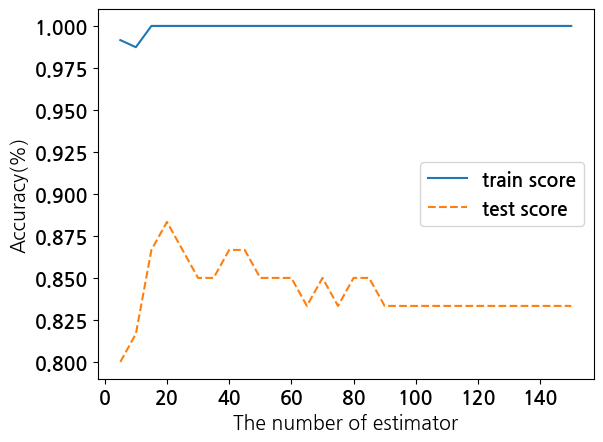

In [220]:
n_estimator_min = 1
n_estimator_max = 31
optimi_estimator(algorithm, algorithm_name,
                 X_train, y_train, X_test, y_test,
                 n_estimator_min, n_estimator_max)

In [221]:
n_estimator = 30

    depth  TrainScore  TestScore
0       1      0.8270     0.8667
1       2      0.8650     0.8833
2       3      0.8734     0.8667
3       4      0.9156     0.8500
4       5      0.9451     0.8500
5       6      0.9747     0.8667
6       7      0.9958     0.8500
7       8      0.9958     0.8667
8       9      1.0000     0.8667
9      10      1.0000     0.8667
10     11      1.0000     0.8500
11     12      1.0000     0.8500
12     13      1.0000     0.8500
13     14      1.0000     0.8500
14     15      1.0000     0.8500
15     16      1.0000     0.8500
16     17      1.0000     0.8500
17     18      1.0000     0.8500
18     19      1.0000     0.8500
19     20      1.0000     0.8500


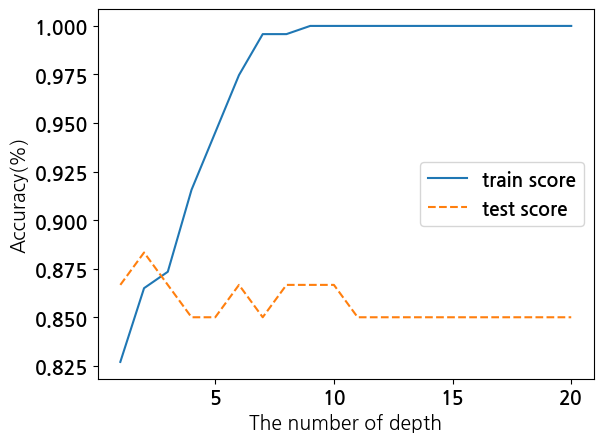

In [222]:
depth_min = 1
depth_max = 21
optimi_maxdepth(algorithm, algorithm_name,
                X_train, y_train, X_test, y_test,
                depth_min, depth_max, n_estimator)

In [223]:
n_depth = 6

    min_samples_split  TrainScore  TestScore
0                   2      0.9747     0.8667
1                   4      0.9620     0.8500
2                   6      0.9536     0.8667
3                   8      0.9325     0.8500
4                  10      0.9325     0.8667
5                  12      0.9283     0.8667
6                  14      0.9241     0.8667
7                  16      0.9198     0.8500
8                  18      0.8903     0.8500
9                  20      0.9072     0.8667
10                 22      0.8945     0.8667
11                 24      0.8945     0.8500
12                 26      0.8819     0.8333
13                 28      0.8819     0.8167
14                 30      0.8861     0.8333
15                 32      0.8776     0.8167
16                 34      0.8903     0.8333
17                 36      0.8734     0.8500
18                 38      0.8819     0.8333
19                 40      0.8819     0.8667
20                 42      0.8903     0.8500
21        

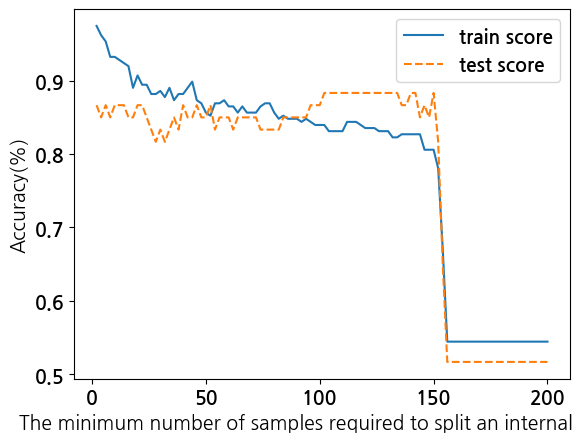

In [224]:
n_split_min = 1
n_split_max = 101
# 'display.max_row' → 'display.max_rows' (복수형, 잘못된 키는 OptionError 발생)
pd.set_option('display.max_rows', 100)
optimi_minsplit(algorithm, algorithm_name,
                X_train, y_train, X_test, y_test,
                n_split_min, n_split_max, n_estimator, n_depth)

In [225]:
n_split = 2

    min_samples_leaf  TrainScore  TestScore
0                  2      0.9578     0.8500
1                  4      0.9198     0.8333
2                  6      0.9156     0.8833
3                  8      0.8861     0.8667
4                 10      0.8776     0.8667
5                 12      0.8692     0.8667
6                 14      0.8608     0.8667
7                 16      0.8523     0.8667
8                 18      0.8650     0.8667
9                 20      0.8481     0.8667
10                22      0.8523     0.8500
11                24      0.8523     0.8833
12                26      0.8481     0.8500
13                28      0.8481     0.8667
14                30      0.8439     0.8667
15                32      0.8439     0.8667
16                34      0.8481     0.8667
17                36      0.8523     0.8667
18                38      0.8439     0.8667
19                40      0.8397     0.8667
20                42      0.8354     0.8833
21                44      0.8270

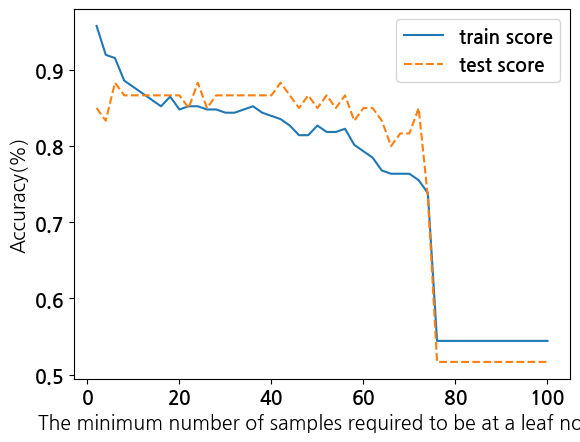

In [226]:
n_leaf_min = 1
n_leaf_max = 51
optimi_minleaf(algorithm, algorithm_name,
               X_train, y_train, X_test, y_test,
               n_leaf_min, n_leaf_max, n_estimator, n_depth, n_split)

In [227]:
n_leaf = 2

# 모델의 정확도 점수 나타낸거 밑에 매트릭스에 나와서 빼고 파란색 그래프만 사용하세요!
## 모델에 영향을 끼친 요인들을 보니 4~5가지 요인 때문에 심장병이 나타나는 것 같다.
## 제가 예측했을 때는 ~ 이런식으로 설명하면 될 것 같습니다.

Accuracy:  0.850
Precision: 0.833
Recall:    0.862
F1-score:  0.847
                    Feature  Importance
2           chest_pain_type       0.156
12              thalassemia       0.150
9             st_depression       0.138
11                       ca       0.120
7   max_heart_rate_achieved       0.079
0                       age       0.076
3    resting_blood_pressure       0.069
4               cholesterol       0.063
1                       sex       0.051
8   exercise_induced_angina       0.039
10                 st_slope       0.038
6                  rest_ecg       0.017
5       fasting_blood_sugar       0.004


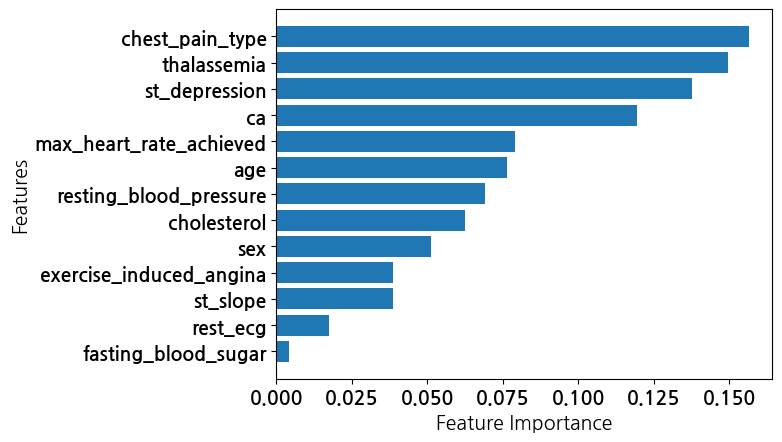

In [228]:
model_final(algorithm, algorithm_name, feature_name,
            X_train, y_train, X_test, y_test,
            n_estimator, n_depth, n_split, n_leaf)

## 위에서 만든 rf 모델을 rf_final안에 학습시켜 정의함

In [229]:
# 하드코딩 파라미터 제거 → model_final 탐색 결과 변수 사용
rf_final = RandomForestClassifier(
    n_estimators=n_estimator,
    max_depth=n_depth,
    min_samples_split=n_split,
    min_samples_leaf=n_leaf,
    random_state=22
)
rf_final.fit(X_train, y_train)
y_pred_rff = rf_final.predict(X_test)

## 여기서 accuracy는 정확도, recall은 민감도를 말하는데 병을 예측하는 경우 recall 값이 높을수록 좋다

# 결론
## 3가지 모델(KNN, MLP, RandomForest)의 최적 하이퍼파라미터를 탐색하여 각각 학습시켰다.
## 최종 성능 비교 결과, **RandomForest**가 Accuracy 0.869, Recall 0.778로 가장 높은 정확도를 기록했다.
## 의료 예측 문제에서는 Recall(민감도)이 중요한데, KNN이 0.808로 가장 높아 임상적 활용도 면에서는 KNN이 유리하다.
## MLP는 이 데이터셋에서 상대적으로 낮은 성능(Accuracy 0.623)을 보였다.

In [230]:
data = {'Randomforest': y_pred_rff, 'MLP': y_pred_mlp}
models = pd.DataFrame(data)

for column in models:
    CM = confusion_matrix(y_test, models[column])
    TN = CM[0][0]; FN = CM[1][0]; TP = CM[1][1]; FP = CM[0][1]
    specificity = TN / (TN + FP)
    loss_log = log_loss(y_test, models[column])
    acc = accuracy_score(y_test, models[column])
    roc = roc_auc_score(y_test, models[column])
    prec = precision_score(y_test, models[column])
    rec = recall_score(y_test, models[column])
    f1 = f1_score(y_test, models[column])
    mathew = matthews_corrcoef(y_test, models[column])
    results = pd.DataFrame(
        [[column, acc, rec, prec, rec, specificity, f1, roc, loss_log, mathew]],
        columns=['Model', 'Accuracy', 'recall', 'Precision',
                 'Sensitivity', 'Specificity', 'F1 Score', 'ROC', 'Log_Loss', 'mathew_corrcoef']
    )
    model_results = pd.concat([model_results, results], ignore_index=True)

model_results

,Model,Accuracy,recall,Precision,Sensitivity,Specificity,F1 Score,ROC,Log_Loss,mathew_corrcoef
0,KNN,0.883333,0.896552,0.866667,0.896552,0.870968,0.881356,0.883760,4.205093,0.767093
1,Randomforest,0.850000,0.862069,0.833333,0.862069,0.838710,0.847458,0.850389,5.406548,0.700389
2,MLP,0.816667,0.896552,0.764706,0.896552,0.741935,0.825397,0.819244,6.608003,0.643881


# RandomForest 특징 중요도 (Feature Importance)

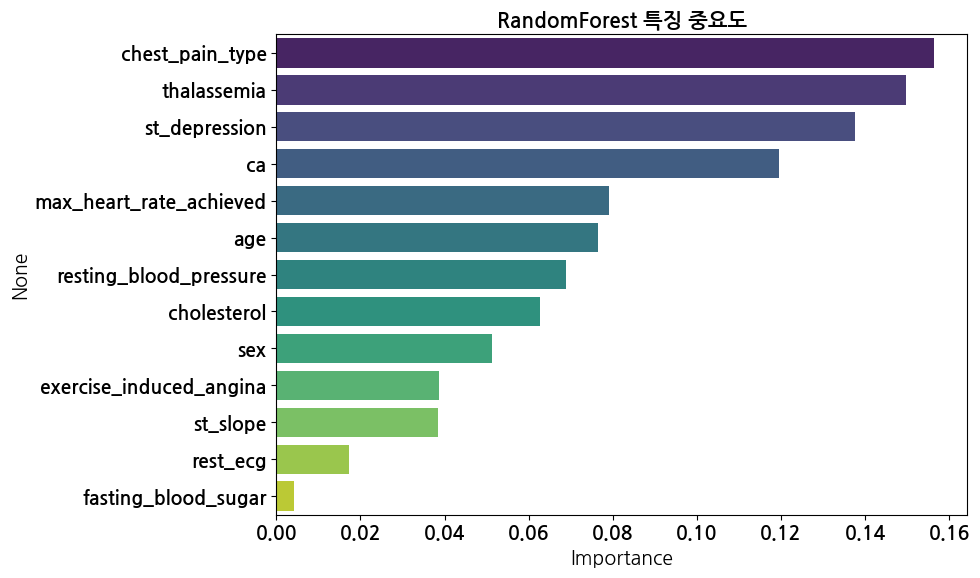

In [231]:
feature_importances = pd.Series(
    rf_final.feature_importances_, index=feature_name
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
# palette without hue deprecated in seaborn 0.13 / error in 0.14 → hue 추가
sns.barplot(x=feature_importances.values, y=feature_importances.index,
            hue=feature_importances.index, palette='viridis', legend=False)
plt.title('RandomForest 특징 중요도', fontsize=15, weight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# ROC Curve 비교 (KNN vs RandomForest vs MLP)

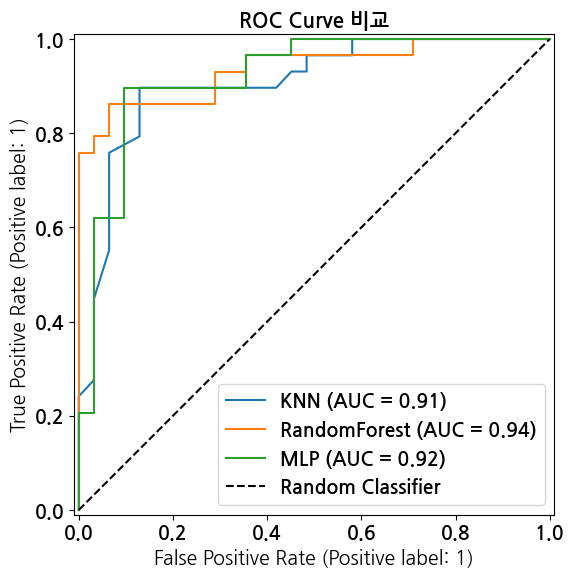

In [232]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))
models_roc = [
    (knn, 'KNN'),
    (rf_final, 'RandomForest'),
    (mlp, 'MLP')
]
for model, name in models_roc:
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title('ROC Curve 비교', fontsize=15, weight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Precision-Recall Curve 비교 (KNN vs RandomForest vs MLP)
## ROC는 클래스 불균형 시 낙관적으로 보이는 경향 → PR Curve로 양성(심장병) 탐지 성능 확인

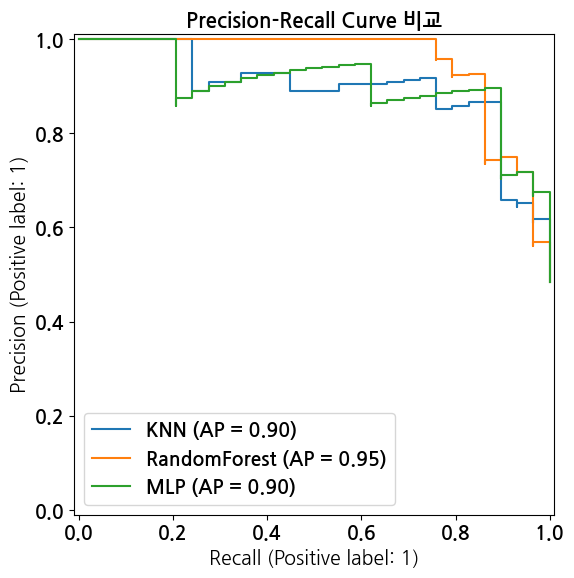

In [233]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(8, 6))
models_pr = [
    (knn, 'KNN'),
    (rf_final, 'RandomForest'),
    (mlp, 'MLP')
]
for model, name in models_pr:
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)

ax.set_title('Precision-Recall Curve 비교', fontsize=15, weight='bold')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

# 모델 성능 비교 (Bar Chart)

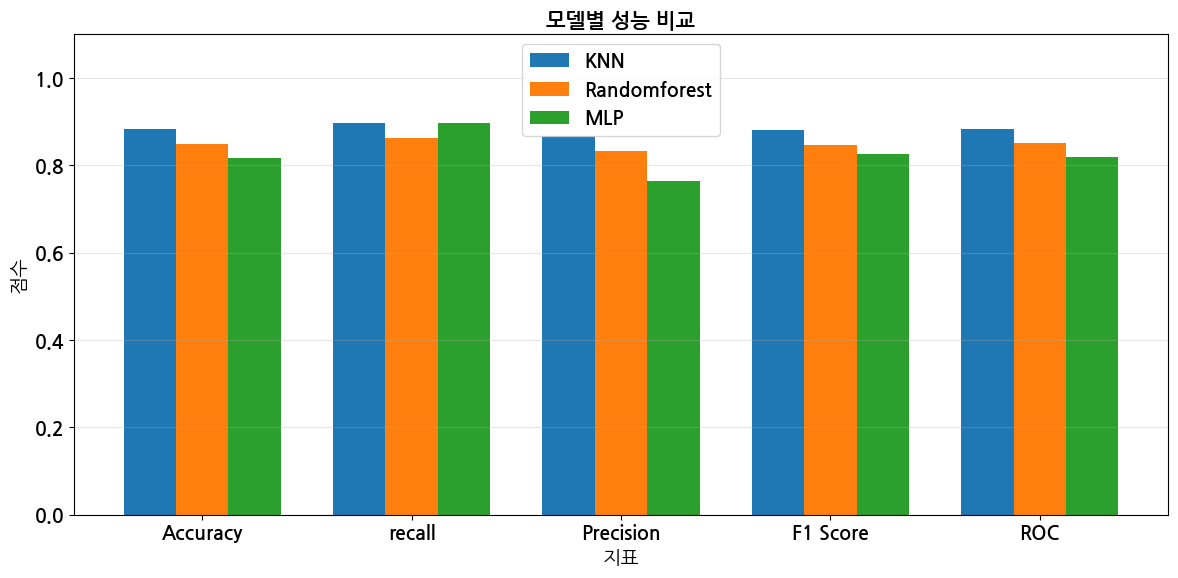

In [234]:
metrics_cols = ['Accuracy', 'recall', 'Precision', 'F1 Score', 'ROC']
mr = model_results[['Model'] + metrics_cols].copy()

x = np.arange(len(metrics_cols))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6))

for i, row in mr.iterrows():
    ax.bar(x + i * width, row[metrics_cols], width, label=row['Model'])

ax.set_xlabel('지표')
ax.set_ylabel('점수')
ax.set_title('모델별 성능 비교', fontsize=15, weight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_cols)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 모델별 학습 곡선 (Learning Curves)
## 과적합/과소적합 여부 확인 — Train Score와 Validation Score 간격이 크면 과적합

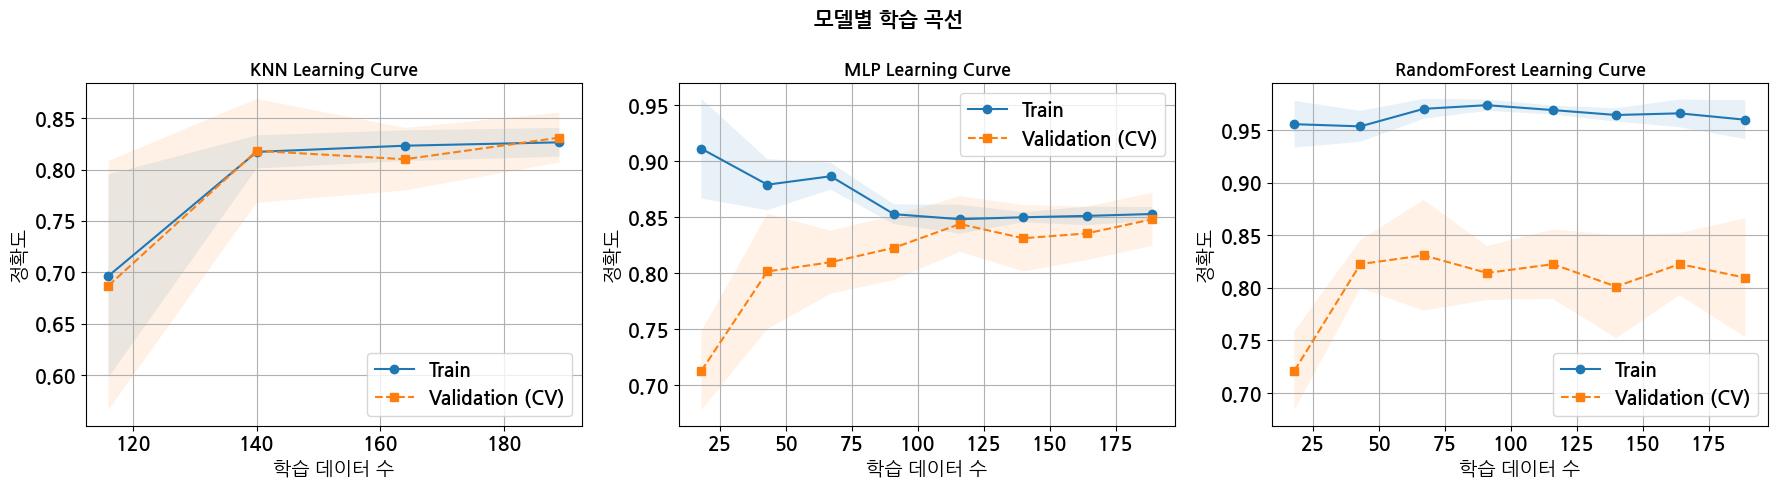

In [235]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
train_sizes = np.linspace(0.1, 1.0, 8)

lc_models = [
    (KNeighborsClassifier(n_neighbors=best_k), 'KNN'),
    (MLPClassifier(hidden_layer_sizes=(30,), activation='relu',
                   solver='adam', max_iter=100, random_state=30), 'MLP'),
    (RandomForestClassifier(n_estimators=n_estimator, max_depth=n_depth,
                             min_samples_split=n_split, min_samples_leaf=n_leaf,
                             random_state=22), 'RandomForest')
]

for ax, (model, name) in zip(axes, lc_models):
    tr_sz, tr_sc, val_sc = learning_curve(
        model, X_train, y_train, cv=5,
        train_sizes=train_sizes, scoring='accuracy'
    )
    tr_mean = tr_sc.mean(axis=1)
    val_mean = val_sc.mean(axis=1)
    tr_std = tr_sc.std(axis=1)
    val_std = val_sc.std(axis=1)

    ax.plot(tr_sz, tr_mean, 'o-', label='Train')
    ax.plot(tr_sz, val_mean, 's--', label='Validation (CV)')
    ax.fill_between(tr_sz, tr_mean - tr_std, tr_mean + tr_std, alpha=0.1)
    ax.fill_between(tr_sz, val_mean - val_std, val_mean + val_std, alpha=0.1)
    ax.set_title(f'{name} Learning Curve', fontsize=13, weight='bold')
    ax.set_xlabel('학습 데이터 수')
    ax.set_ylabel('정확도')
    ax.legend()
    ax.grid(True)

plt.suptitle('모델별 학습 곡선', fontsize=15, weight='bold')
plt.tight_layout()
plt.show()